In [1]:
import geopandas as gpd
import osmnx as ox

In [2]:
highways = gpd.read_file(r'D:\QGIS\Астрахань\data\hghwys_nextgis\highway-line.shp', encoding='utf-8')
highways.head()

,name,name_en,name_ru,ref,highway,oneway,bridge,tunnel,maxspeed,lanes,width,surface,osn_type,osn_id,geometry
0,Новый мост,New Bridge,None,Р-22,trunk,no,None,None,60,None,19,asphalt,way,23449427,"LINESTRING (48.01198 46.37211, 48.0132 46.37171)"
1,Новый мост,New Bridge,None,Р-22,trunk,no,yes,None,60,4,19,asphalt,way,23449428,"LINESTRING (48.03418 46.3648, 48.03985 46.3629..."
2,Новый мост,New Bridge,None,Р-22,trunk,no,yes,None,60,4,19,asphalt,way,23449429,"LINESTRING (48.01535 46.37101, 48.02009 46.369..."
3,Новый мост,New Bridge,None,Р-22,trunk,no,None,None,60,None,19,asphalt,way,23449430,"LINESTRING (48.02532 46.36771, 48.02615 46.367..."
4,Новый мост,New Bridge,None,Р-22,trunk,no,yes,None,60,None,19,asphalt,way,23449433,"LINESTRING (48.00909 46.37307, 48.01095 46.37245)"


In [3]:
from graphs.algorithms import graph_rise_from_gpkg


G = graph_rise_from_gpkg(roads        = highways,
                         columns_list = ['name', 'highway', 'oneway', 'lanes'])

print(G.number_of_nodes(), G.number_of_edges())

511063 1079406


In [4]:
Gs = ox.simplify_graph(G)
print(Gs.number_of_nodes(), Gs.number_of_edges())

76977 213835


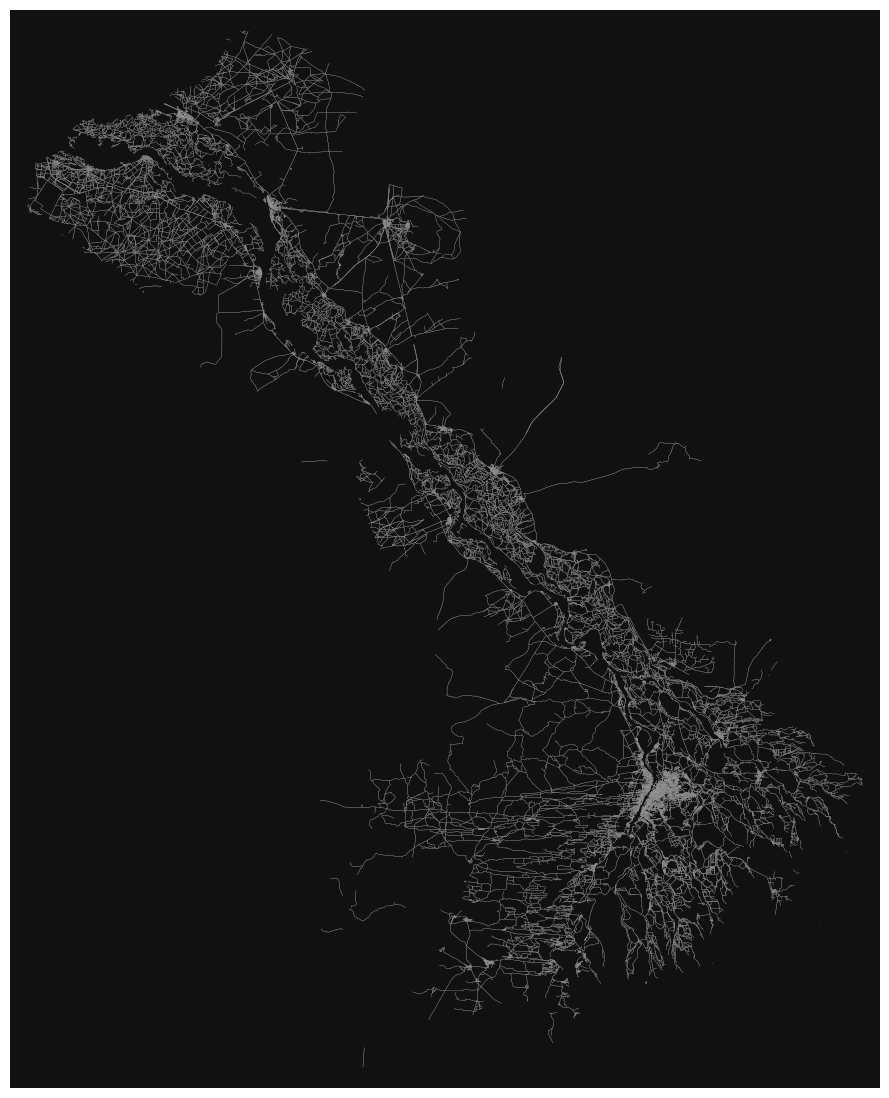

(<Figure size 1400x1400 with 1 Axes>, <Axes: >)

In [11]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, figsize=(14,14))

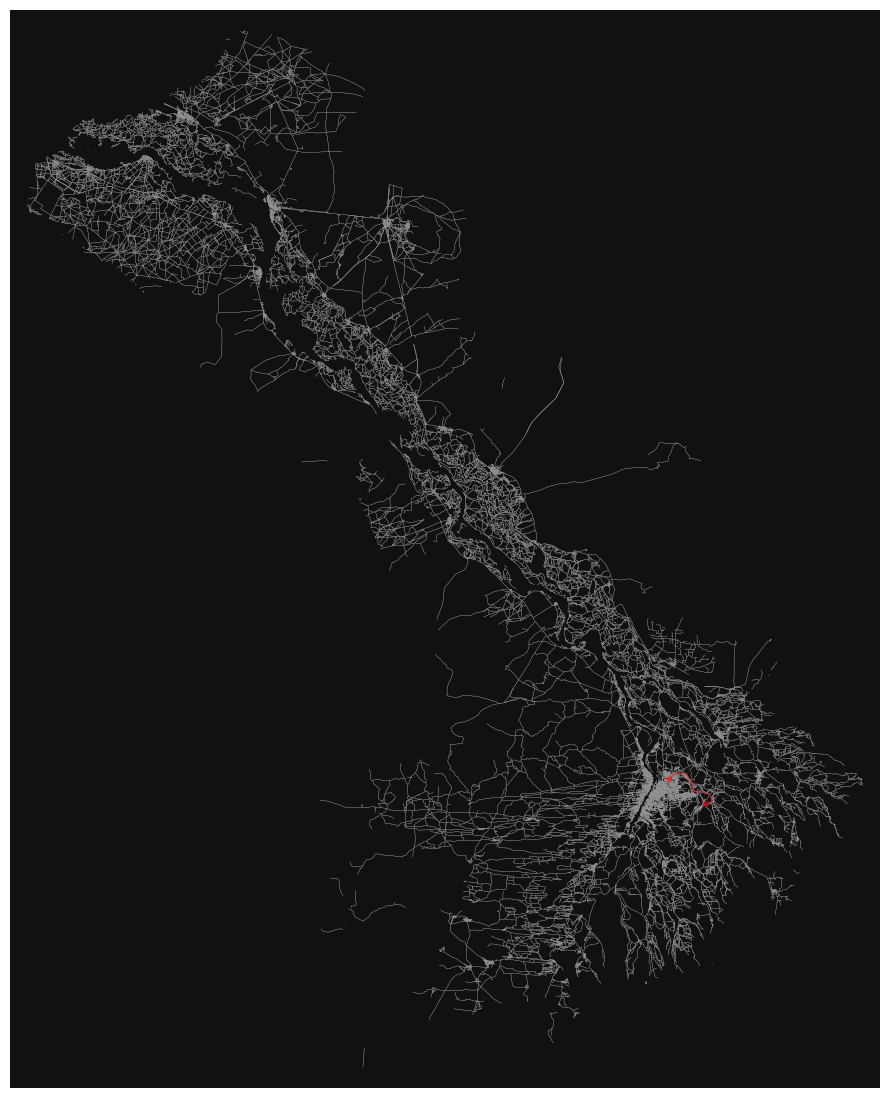

(<Figure size 1400x1400 with 1 Axes>, <Axes: >)

In [14]:
orig = list(Gs)[2000]
dest = list(Gs)[15500]

route = ox.shortest_path(Gs, orig=orig, dest=dest)
ox.plot_graph_route(Gs, route, 
    route_linewidth = 1,
    route_color     = 'red',
    orig_dest_size  = 20,
    node_size       = 0, 
    edge_linewidth  = 0.2, 
    figsize         = (14,14)
)

## Загрузка / сохранение

In [5]:
ox.save_graphml(Gs, 't.ml')

In [6]:
Gss = ox.load_graphml('t.ml')

In [11]:
h = ox.graph_to_gdfs(Gs, nodes=False)
h.head(10)

highway oneway  reversed       length  \
u    v      key                                                 
1    2288   0    secondary_link   True     False    30.969023   
     444650 0             trunk  False     False   633.650265   
     15     0             trunk  False     False  1318.676253   
2288 426214 0           footway    NaN     False    12.290620   
     2293   0    secondary_link   True     False   162.398109   
     426273 0           footway    NaN     False   459.259173   
10   5214   0             trunk  False     False  1257.649221   
     1296   0             trunk   True     False    67.678237   
15   5213   0             trunk  False     False    63.069790   
     1      0             trunk  False     False  1318.676253   

                                              name  \
u    v      key                                      
1    2288   0                                  NaN   
     444650 0    [Новый мост, Магистральная улица]   
     15     0                           Новый мост   
2288 426214 0                                  NaN   
     2293   0                                  NaN   
     426273 0                                  NaN   
10   5214   0                           Новый мост   
     1296   0                   улица Анри Барбюса   
15   5213   0                           Новый мост   
     1      0                           Новый мост   

                                                          geometry lanes  
u    v      key                                                           
1    2288   0     LINESTRING (48.0132 46.37171, 48.01294 46.37192)   NaN  
     444650 0    LINESTRING (48.0132 46.37171, 48.01198 46.3721...   NaN  
     15     0    LINESTRING (48.0132 46.37171, 48.01535 46.3710...     4  
2288 426214 0    LINESTRING (48.01294 46.37192, 48.01308 46.37187)   NaN  
     2293   0    LINESTRING (48.01294 46.37192, 48.01281 46.372...   NaN  
     426273 0    LINESTRING (48.01294 46.37192, 48.01181 46.372...   NaN  
10   5214   0    LINESTRING (48.0451 46.36209, 48.04431 46.3621...     4  
     1296   0    LINESTRING (48.0451 46.36209, 48.04535 46.3620...     2  
15   5213   0      LINESTRING (48.02866 46.3666, 48.0294 46.36635)     4  
     1      0    LINESTRING (48.02866 46.3666, 48.02615 46.3674...     4

In [12]:
h = ox.graph_to_gdfs(Gss, nodes=False)
h.head(10)

highway oneway  reversed       length  \
u    v      key                                                 
1    2288   0    secondary_link   True     False    30.969023   
     444650 0             trunk  False     False   633.650265   
     15     0             trunk  False     False  1318.676253   
2288 426214 0           footway    NaN     False    12.290620   
     2293   0    secondary_link   True     False   162.398109   
     426273 0           footway    NaN     False   459.259173   
10   5214   0             trunk  False     False  1257.649221   
     1296   0             trunk   True     False    67.678237   
15   5213   0             trunk  False     False    63.069790   
     1      0             trunk  False     False  1318.676253   

                                              name  \
u    v      key                                      
1    2288   0                                  NaN   
     444650 0    [Новый мост, Магистральная улица]   
     15     0                           Новый мост   
2288 426214 0                                  NaN   
     2293   0                                  NaN   
     426273 0                                  NaN   
10   5214   0                           Новый мост   
     1296   0                   улица Анри Барбюса   
15   5213   0                           Новый мост   
     1      0                           Новый мост   

                                                          geometry lanes  
u    v      key                                                           
1    2288   0     LINESTRING (48.0132 46.37171, 48.01294 46.37192)   NaN  
     444650 0    LINESTRING (48.0132 46.37171, 48.01198 46.3721...   NaN  
     15     0    LINESTRING (48.0132 46.37171, 48.01535 46.3710...     4  
2288 426214 0    LINESTRING (48.01294 46.37192, 48.01308 46.37187)   NaN  
     2293   0    LINESTRING (48.01294 46.37192, 48.01281 46.372...   NaN  
     426273 0    LINESTRING (48.01294 46.37192, 48.01181 46.372...   NaN  
10   5214   0    LINESTRING (48.0451 46.36209, 48.04431 46.3621...     4  
     1296   0    LINESTRING (48.0451 46.36209, 48.04535 46.3620...     2  
15   5213   0      LINESTRING (48.02866 46.3666, 48.0294 46.36635)     4  
     1      0    LINESTRING (48.02866 46.3666, 48.02615 46.3674...     4

In [9]:
h['oneway']

u       v       key
1       2288    0       True
        444650  0      False
        15      0      False
2288    426214  0        NaN
        2293    0       True
                       ...  
511044  511045  0        NaN
511045  511044  0        NaN
511046  511047  0        NaN
511047  511046  0        NaN
511062  406466  0        NaN
Name: oneway, Length: 213835, dtype: object

In [10]:
for i, d in h[:20].iterrows():
    print(d['oneway'], type(d['oneway']))

True <class 'bool'>
False <class 'bool'>
False <class 'bool'>
nan <class 'float'>
True <class 'bool'>
nan <class 'float'>
False <class 'bool'>
True <class 'bool'>
False <class 'bool'>
False <class 'bool'>
True <class 'bool'>
False <class 'bool'>
False <class 'bool'>
nan <class 'float'>
nan <class 'float'>
nan <class 'float'>
nan <class 'float'>
nan <class 'float'>
nan <class 'float'>
nan <class 'float'>
